In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import VotingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.base import BaseEstimator, RegressorMixin, clone
from lightgbm import LGBMRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


def _regressor_tags_compat(self):
    tags = BaseEstimator.__sklearn_tags__(self)
    tags.estimator_type = "regressor"
    tags.regressor_tags = RegressorTags()
    tags.target_tags.required = True
    return tags


RegressorMixin.__sklearn_tags__ = _regressor_tags_compat

In [2]:
#df = pd.read_csv('database/test.csv')
df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,-,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


In [3]:
df.columns.tolist()

['ID',
 'Débitos',
 'Fabricante',
 'Modelo',
 'Ano',
 'Categoria',
 'Couro',
 'Combustivel',
 'Volume_motor',
 'Km',
 'Cilindros',
 'Tipo_cambio',
 'Tração',
 'Portas',
 'Rodas',
 'Cor',
 'Airbags',
 'Preco',
 'Numero_proprietarios',
 'Data_ultima_lavagem',
 'Adesivos_personalizados',
 'Radio_AM_FM',
 'Historico_troca_oleo',
 'Codigo_concessionaria',
 'Classificacao_Veiculo',
 'Faixa_Preco']

### Coluna ID excluída pois são valores aleatórios

In [4]:
#colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco", "Codigo_concessionaria", "Classificacao_Veiculo"]
colunas_excluir = ["ID"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Débitos

In [5]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

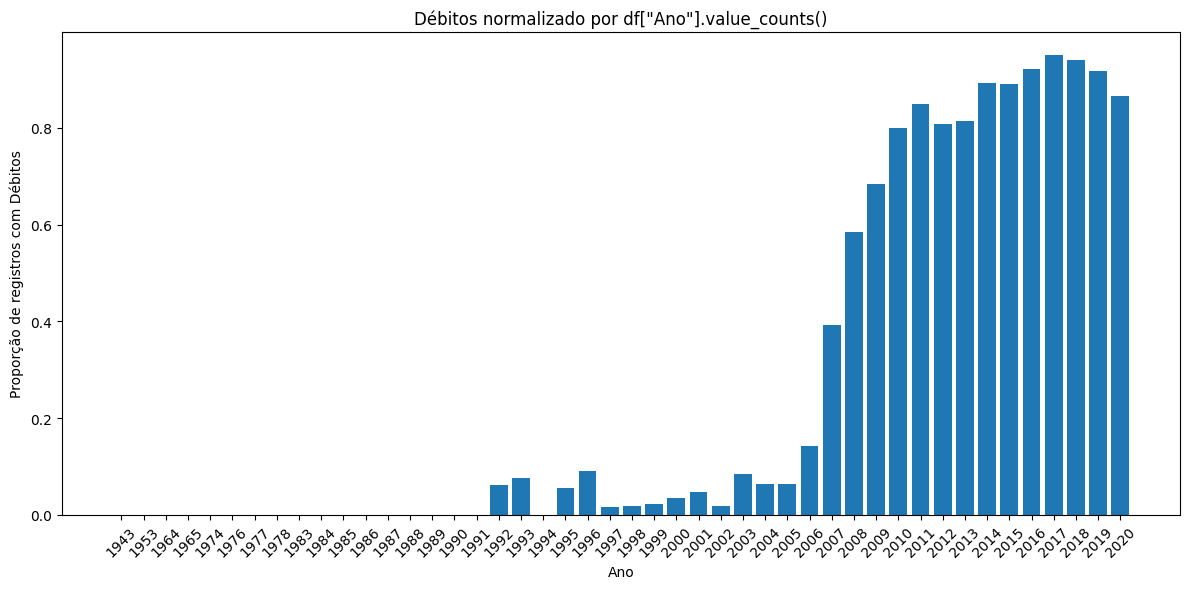

In [6]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df['Débitos'] = df['Débitos'].fillna(0)
df['Débitos'].isna().sum()

0

### Coluna Fabricante

In [8]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           1794
HYUNDAI          1496
MERCEDES-BENZ     939
FORD              507
BMW               483
HONDA             469
CHEVROLET         468
LEXUS             460
NISSAN            275
VOLKSWAGEN        250
SSANGYONG         215
OPEL              185
KIA               176
MITSUBISHI        136
SUBARU            127
AUDI              114
MAZDA              81
JEEP               61
DAEWOO             45
SUZUKI             44
DODGE              39
FIAT               39
PORSCHE            29
LAND ROVER         28
VAZ                27
MINI               22
RENAULT            21
JAGUAR             19
CHRYSLER           12
INFINITI           11
ACURA              10
SKODA               9
LINCOLN             9
CADILLAC            9
DAIHATSU            8
GMC                 8
GAZ                 7
VOLVO               7
BUICK               5
PEUGEOT             4
CITROEN             4
ISUZU               3
SCION               3
UAZ                 3
MOSKVICH            3

In [9]:
df["Fabricante"].isna().sum()

0

### Coluna Modelo

In [10]:
df["Modelo"].value_counts()

Modelo
Prius              507
Camry              474
Elantra            407
Santa FE           264
Sonata             251
                  ... 
E 350 w211           1
Sonata HYBRID        1
Prius V ALPINA       1
Sprinter 315CDI      1
240                  1
Name: count, Length: 1032, dtype: int64

In [11]:
df["Modelo"].isna().sum()

0

### Coluna Ano

In [12]:
df["Ano"].value_counts()

Ano
2012    994
2014    946
2013    943
2011    736
2010    713
2016    632
2015    608
2017    430
2008    322
2009    259
2018    234
2007    217
2004    172
2003    165
2002    158
2005    156
2006    147
2019    147
2000    119
1998    109
2001    105
1999     90
1997     61
1996     55
1995     54
1994     21
1992     16
2020     15
1993     13
1988      7
1991      7
1989      6
1990      5
1984      5
1983      3
1974      2
1953      2
1985      2
1986      2
1964      1
1977      1
1987      1
1943      1
1978      1
1965      1
1976      1
Name: count, dtype: int64

In [13]:
df["Ano"].isna().sum()

0

### Coluna Categoria

In [14]:
df["Categoria"].value_counts()

Categoria
Sedan             3826
SUV               2555
Hatchback         1314
Minivan            285
Cupê               261
Universal          156
Microonibus        127
Vagao de carga     115
Picape              23
Conversivel         17
Limousine            6
Name: count, dtype: int64

In [15]:
df["Categoria"].isna().sum()

0

### Coluna Couro

In [16]:
df["Couro"].value_counts()

Couro
Sim    6192
Nao    2493
Name: count, dtype: int64

In [17]:
df["Couro"].isna().sum()

0

### Coluna Combustivel

In [18]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       1966
Hibrido        1710
GASOLINA       1184
Gasol.          975
gasolina        777
Diesel          721
DIESEL          436
Dies.           379
diesel          305
Gás Natural     232
Name: count, dtype: int64

In [19]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    
    # remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
    return texto

mapeamento = {
    "gasolina": "Gasolina",
    "gasol.": "Gasolina",
    "diesel": "Diesel",
    "dies.": "Diesel",
    "hibrido": "Híbrido",
    "gas natural": "Gás Natural",
    "GASOLINA": "Gasolina",
}

df["Combustivel"] = (
    df["Combustivel"]
    .apply(normalizar_texto)
    .map(mapeamento)
    .fillna(df["Combustivel"])
)

In [20]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       4902
Diesel         1841
Híbrido        1710
Gás Natural     232
Name: count, dtype: int64

In [21]:
df["Combustivel"].isna().sum()

0

### Coluna Volume_motor

In [22]:
df["Volume_motor"].value_counts()

Volume_motor
2            1556
2.5          1106
1.8           831
1.6           670
1.5           601
             ... 
2.1 Turbo       1
0.5             1
5.9             1
3.7 Turbo       1
6.4             1
Name: count, Length: 96, dtype: int64

In [23]:
df["Volume_motor"] = (
    df["Volume_motor"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

In [24]:
df["Volume_motor"].value_counts()

Volume_motor
2.0    1751
2.5    1144
1.8     917
1.6     719
1.5     634
3.5     564
3.0     504
2.4     468
1.3     263
1.4     224
2.2     197
4.6     174
3.3     105
1.7      95
2.7      89
3.2      77
2.3      62
3.6      59
4.4      58
4.7      57
1.2      57
1.0      55
4.0      46
3.7      35
1.9      35
5.0      34
2.8      34
5.5      32
5.7      24
4.8      20
3.8      19
2.9      13
6.2      12
0.7      12
0.4      11
4.2      10
4.5       7
5.3       6
0.6       6
2.1       5
0.8       5
0.0       5
0.2       5
3.4       4
6.3       4
2.6       4
5.4       4
1.1       3
4.3       3
5.6       2
6.0       2
0.3       2
5.9       1
0.5       1
6.8       1
6.7       1
7.3       1
0.1       1
3.1       1
6.4       1
Name: count, dtype: int64

In [25]:
df["Volume_motor"].isna().sum()

0

### Coluna Km

In [26]:
df["Km"].value_counts()

Km
0 km         295
200000 km     71
150000 km     62
160000 km     57
100000 km     55
            ... 
132043 km      1
18900 km       1
152480 km      1
453000 km      1
119484 km      1
Name: count, Length: 3745, dtype: int64

In [27]:
df["Km"] = (
    df["Km"]
    .astype(str)
    .str.replace(" km", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df["Km"] = pd.to_numeric(df["Km"], errors="coerce")

In [28]:
df["Km"].value_counts()

Km
0.0         295
200000.0     71
150000.0     62
160000.0     57
100000.0     55
           ... 
132043.0      1
18900.0       1
152480.0      1
453000.0      1
119484.0      1
Name: count, Length: 3745, dtype: int64

In [29]:
df['Km'].isna().sum()

870

In [30]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
779,308.0,TOYOTA,Prius 2014,2014,Sedan,Sim,Híbrido,1.8,0.0,12,...,12,7997.0,3,2022-11-22,Não,AM,1,2192,Usado,Econômico
5081,0.0,BMW,318,2000,Sedan,Nao,Gás Natural,1.9,0.0,4,...,8,7840.0,5,2020-04-13,Não,FM,2,8206,Usado,Econômico
2920,1055.0,MERCEDES-BENZ,E 350,2013,Cupê,Sim,Diesel,3.5,0.0,6,...,12,627.0,3,2020-01-20,Não,AM/FM,10,7514,Usado,Econômico
5087,1018.0,AUDI,A6,2011,Sedan,Sim,Gasolina,3.0,0.0,6,...,12,1098.0,2,2021-01-31,Não,AM,3,4438,Usado,Econômico
7748,0.0,HONDA,FIT,2003,Hatchback,Nao,Gasolina,1.5,0.0,4,...,4,30.0,4,2022-05-28,Sim,AM,9,6697,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8658,503.0,TOYOTA,Yaris,2012,Hatchback,Nao,Gasolina,1.5,NaN,4,...,8,12231.0,2,2022-06-26,Não,AM,4,6801,Usado,Econômico
8664,382.0,CHEVROLET,Volt,2017,Hatchback,Sim,Híbrido,1.5,NaN,4,...,0,26030.0,5,2020-02-03,Não,AM/FM,9,1086,Usado,Médio
8665,574.0,HONDA,Insight,2010,Hatchback,Sim,Híbrido,1.3,NaN,4,...,0,220.0,5,2022-06-27,Sim,FM,5,4031,Usado,Econômico
8667,1408.0,FORD,Transit,2007,Microonibus,Nao,Diesel,2.2,NaN,4,...,2,NaN,5,2020-09-12,Não,AM,6,7747,Usado,NaN


In [31]:
# Regras adicionais para tratar quilometragens improvaveis antes da modelagem.
# Mantive 2023 como referencia porque o notebook ja usa essa data em Data_ultima_lavagem.
ano_ref = 2023

df["Idade"] = (ano_ref - df["Ano"]).clip(lower=1)
df.loc[(df["Km"] >= 4_000_000.0) | (df["Km"] < 10_000), "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]
km_str = df["Km"].round().astype("Int64").astype("string")

padrao_km_repetido = km_str.str.fullmatch(r"(\d)\1{4,}", na=False)
valores_km_sentinela = df["Km"].isin([
    11_111, 22_222, 33_333, 44_444, 55_555, 66_666, 77_777, 88_888, 99_999,
    111_111, 222_222, 333_333, 444_444, 555_555, 666_666, 777_777, 888_888, 999_999,
    1_111_111, 2_222_222, 123_456, 1_234_567, 101_010, 121_212
])

regra_km_suspeito = (
    (df["Km"] >= 1_000_000) |
    (df["Km_por_ano"] > 70_000) |
    ((df["Idade"] >= 2) & (df["Km_por_ano"] < 1_000)) |
    padrao_km_repetido |
    valores_km_sentinela
)

print("Km marcados como ausentes por regras adicionais:", int(regra_km_suspeito.sum()))
df.loc[regra_km_suspeito, "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]

Km marcados como ausentes por regras adicionais: 139


In [32]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7392,0.0,TOYOTA,Aqua,2014,Sedan,Sim,Híbrido,1.5,10000.0,4,...,3,2020-09-10,Não,FM,10,4106,Usado,Econômico,9,1111.111111
3220,640.0,BMW,X1,2013,SUV,Sim,Gasolina,2.0,10000.0,4,...,4,2022-02-12,Sim,AM,0,9227,Usado,Médio,10,1000.000000
5906,779.0,TOYOTA,Camry,2013,Sedan,Nao,Gasolina,2.5,10000.0,6,...,3,2020-03-10,Sim,AM,2,8497,Usado,Médio,10,1000.000000
1183,1077.0,TOYOTA,CHR,2019,SUV,Sim,Gasolina,2.0,10003.0,4,...,5,2022-04-10,Sim,AM,9,5357,Semi-novo,Econômico,4,2500.750000
7309,1077.0,HYUNDAI,Santa FE,2019,SUV,Sim,Diesel,2.0,10120.0,4,...,1,2021-11-16,Não,FM,8,9031,Semi-novo,NaN,4,2530.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8673,0.0,OPEL,Astra,1994,Sedan,Nao,Gás Natural,1.6,NaN,4,...,1,2021-12-19,Sim,AM,10,2340,Usado,Econômico,29,NaN
8674,0.0,JAGUAR,E-pace p200,2020,SUV,Nao,Gasolina,2.0,NaN,4,...,4,2020-01-28,Não,AM,1,3870,Semi-novo,Muito Luxo,3,NaN
8676,0.0,VOLKSWAGEN,Passat,2004,Sedan,Sim,Gasolina,1.8,NaN,4,...,4,2021-11-02,Não,AM,8,2131,Usado,Econômico,19,NaN
8681,2004.0,MERCEDES-BENZ,240,1998,Sedan,Nao,Gasolina,2.4,NaN,6,...,5,2020-01-18,Não,FM,6,8892,Usado,Econômico,25,NaN


### Coluna Cilindros

In [33]:
df["Cilindros"].value_counts()

Cilindros
4     6428
6     1602
8      469
5       66
3       51
2       20
12      18
1       16
10       7
16       3
7        3
9        1
14       1
Name: count, dtype: int64

In [34]:
df['Cilindros'].isna().sum()

0

### Coluna Tipo_cambio

In [35]:
df["Tipo_cambio"].value_counts()

Tipo_cambio
Automatico    6046
Tiptronic     1405
Manual         865
Variator       369
Name: count, dtype: int64

In [36]:
df['Tipo_cambio'].isna().sum()

0

### Coluna Tração

In [37]:
df["Tração"].value_counts()

Tração
Dianteira    5744
4x4          1879
Traseira     1062
Name: count, dtype: int64

In [38]:
df['Tração'].isna().sum()

0

### Coluna Portas

In [39]:
df["Portas"].value_counts()

Portas
4-5    8243
2-3     387
>5       55
Name: count, dtype: int64

In [40]:
df['Portas'].isna().sum()

0

### Coluna Rodas

In [41]:
df["Rodas"].value_counts()

Rodas
21    310
19    299
6     297
20    296
15    295
24    291
3     291
29    285
25    284
23    279
4     277
13    276
32    272
31    271
2     271
11    270
1     269
27    269
18    267
12    266
5     261
10    259
9     259
8     259
17    258
22    256
30    255
14    253
7     252
16    249
26    247
28    242
Name: count, dtype: int64

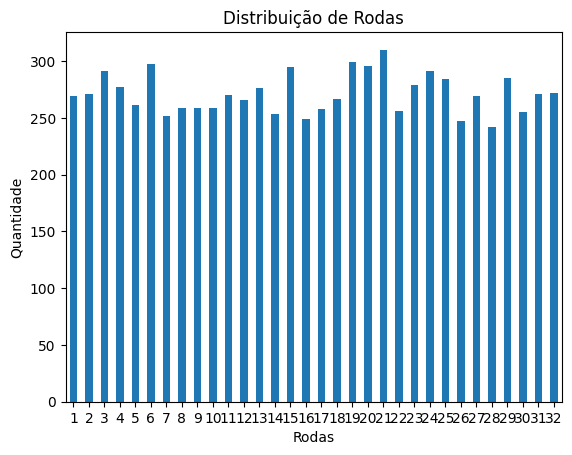

In [42]:
import matplotlib.pyplot as plt

df["Rodas"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rodas")
plt.ylabel("Quantidade")
plt.title("Distribuição de Rodas")
plt.xticks(rotation=0)
plt.show()

In [43]:
df['Rodas'].isna().sum()

0

In [44]:
## Decidido por excluir a coluna "Rodas" devido a não conseguir entender o significado desse campo.
colunas_excluir = ["Rodas"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Cor

In [45]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         640
Red          311
Verde        142
Marrom        87
Vermelho      85
Bege          64
Azul ceu      59
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [46]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

mapeamento_cor = {
    "preto": "Preto",
    "branco": "Branco",
    "prata": "Prata",
    "cinza": "Cinza",
    "azul": "Azul",
    "azul ceu": "Azul",
    "red": "Vermelho",
    "vermelho": "Vermelho",
    "verde": "Verde",
    "marrom": "Marrom",
    "bege": "Bege",
    "amarelo": "Amarelo",
    "dourado": "Dourado",
    "laranja": "Laranja",
    "roxo": "Roxo",
    "rosa": "Rosa"
}

df["Cor"] = (
    df["Cor"]
    .apply(normalizar_texto)
    .map(mapeamento_cor)
    .fillna(df["Cor"])
)

In [47]:
df["Cor"].value_counts()

Cor
Preto       2354
Branco      2037
Prata       1648
Cinza       1089
Azul         699
Vermelho     396
Verde        142
Marrom        87
Bege          64
Dourado       57
Amarelo       55
Laranja       26
Roxo          19
Rosa          12
Name: count, dtype: int64

In [48]:
df['Cor'].isna().sum()

0

### Coluna Airbags

In [49]:
df["Airbags"].value_counts()

Airbags
12    2673
4     2418
0     1071
8      733
6      620
2      521
10     395
5       47
16      45
7       40
1       38
9       27
3       23
11      20
14      10
15       4
Name: count, dtype: int64

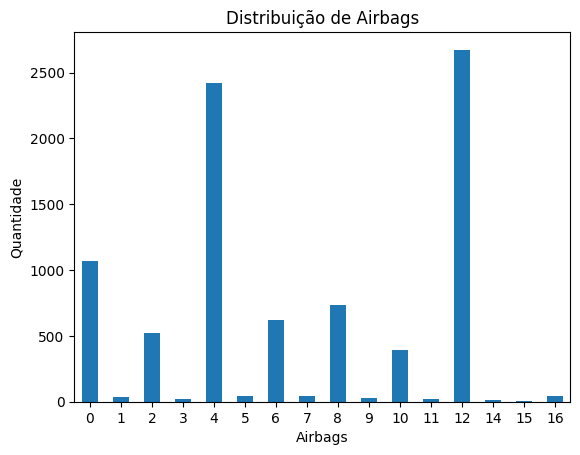

In [50]:
df["Airbags"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Airbags")
plt.ylabel("Quantidade")
plt.title("Distribuição de Airbags")
plt.xticks(rotation=0)
plt.show()

In [51]:
df['Airbags'].isna().sum()

0

### Coluna Preco

In [52]:
df['Preco'].describe()

count      8261.000000
mean      17700.684421
std       26383.538613
min           1.000000
25%        4861.000000
50%       13172.000000
75%       22825.000000
max      886993.000000
Name: Preco, dtype: float64

In [53]:
df["Preco"] = pd.to_numeric(df["Preco"], errors="coerce")
df = df.sort_values("Preco", ascending=True)
df.head(8000)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico,24,5092.958333
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,3,2022-07-29,Não,AM,6,3838,Usado,Econômico,7,5857.142857
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico,19,17263.157895
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico,9,14933.333333
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico,19,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4537,0.0,BMW,X5,2013,SUV,Sim,Diesel,3.0,NaN,6,...,3,2022-09-07,Não,FM,6,3069,Usado,Luxo,10,NaN
3214,0.0,PORSCHE,Cayenne,2011,SUV,Sim,Gasolina,3.5,171000.0,6,...,3,2020-03-22,Não,AM/FM,7,4319,Usado,Luxo,12,14250.000000
7896,1053.0,MERCEDES-BENZ,ML 350,2014,SUV,Sim,Diesel,3.5,190000.0,6,...,4,2020-07-02,Não,AM/FM,0,7069,Usado,Luxo,9,21111.111111
5608,1079.0,HONDA,Civic,2018,Sedan,Sim,Gasolina,2.0,26134.0,4,...,2,2022-01-07,Sim,AM/FM,3,7158,Semi-novo,Luxo,5,5226.800000


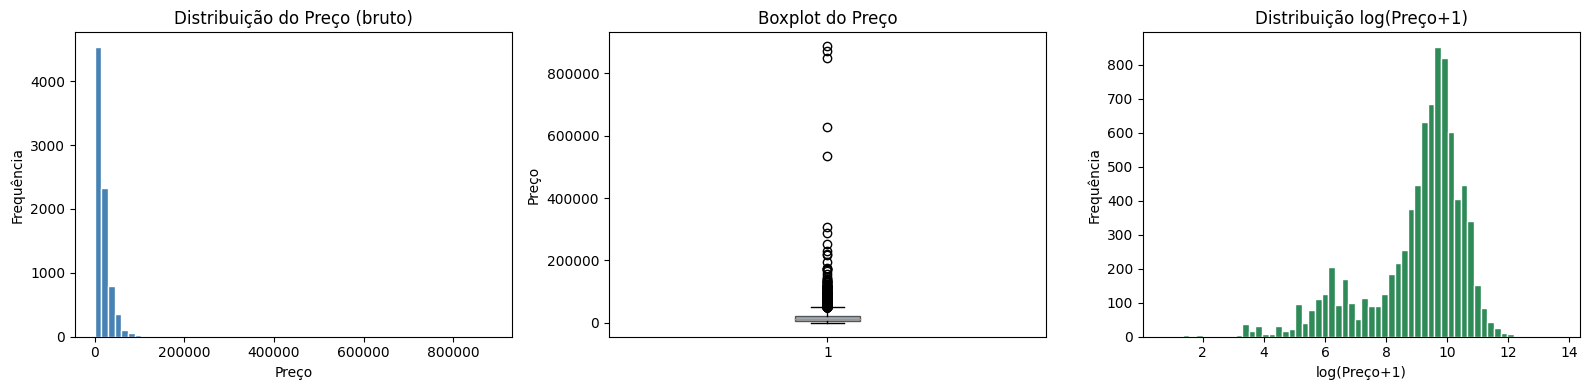

Estatísticas do Preço:
count      8261.00
mean      17700.68
std       26383.54
min           1.00
25%        4861.00
50%       13172.00
75%       22825.00
max      886993.00
Name: Preco, dtype: float64


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df['Preco'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Preço (bruto)')
axes[0].set_xlabel('Preço')
axes[0].set_ylabel('Frequência')

# Boxplot
axes[1].boxplot(df['Preco'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot do Preço')
axes[1].set_ylabel('Preço')

# Log-transformado
log_preco = np.log1p(df['Preco'].dropna())
axes[2].hist(log_preco, bins=60, color='seagreen', edgecolor='white')
axes[2].set_title('Distribuição log(Preço+1)')
axes[2].set_xlabel('log(Preço+1)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
#plt.savefig('distribuicao_preco.png', dpi=150)
plt.show()

print('Estatísticas do Preço:')
print(df['Preco'].describe().round(2))

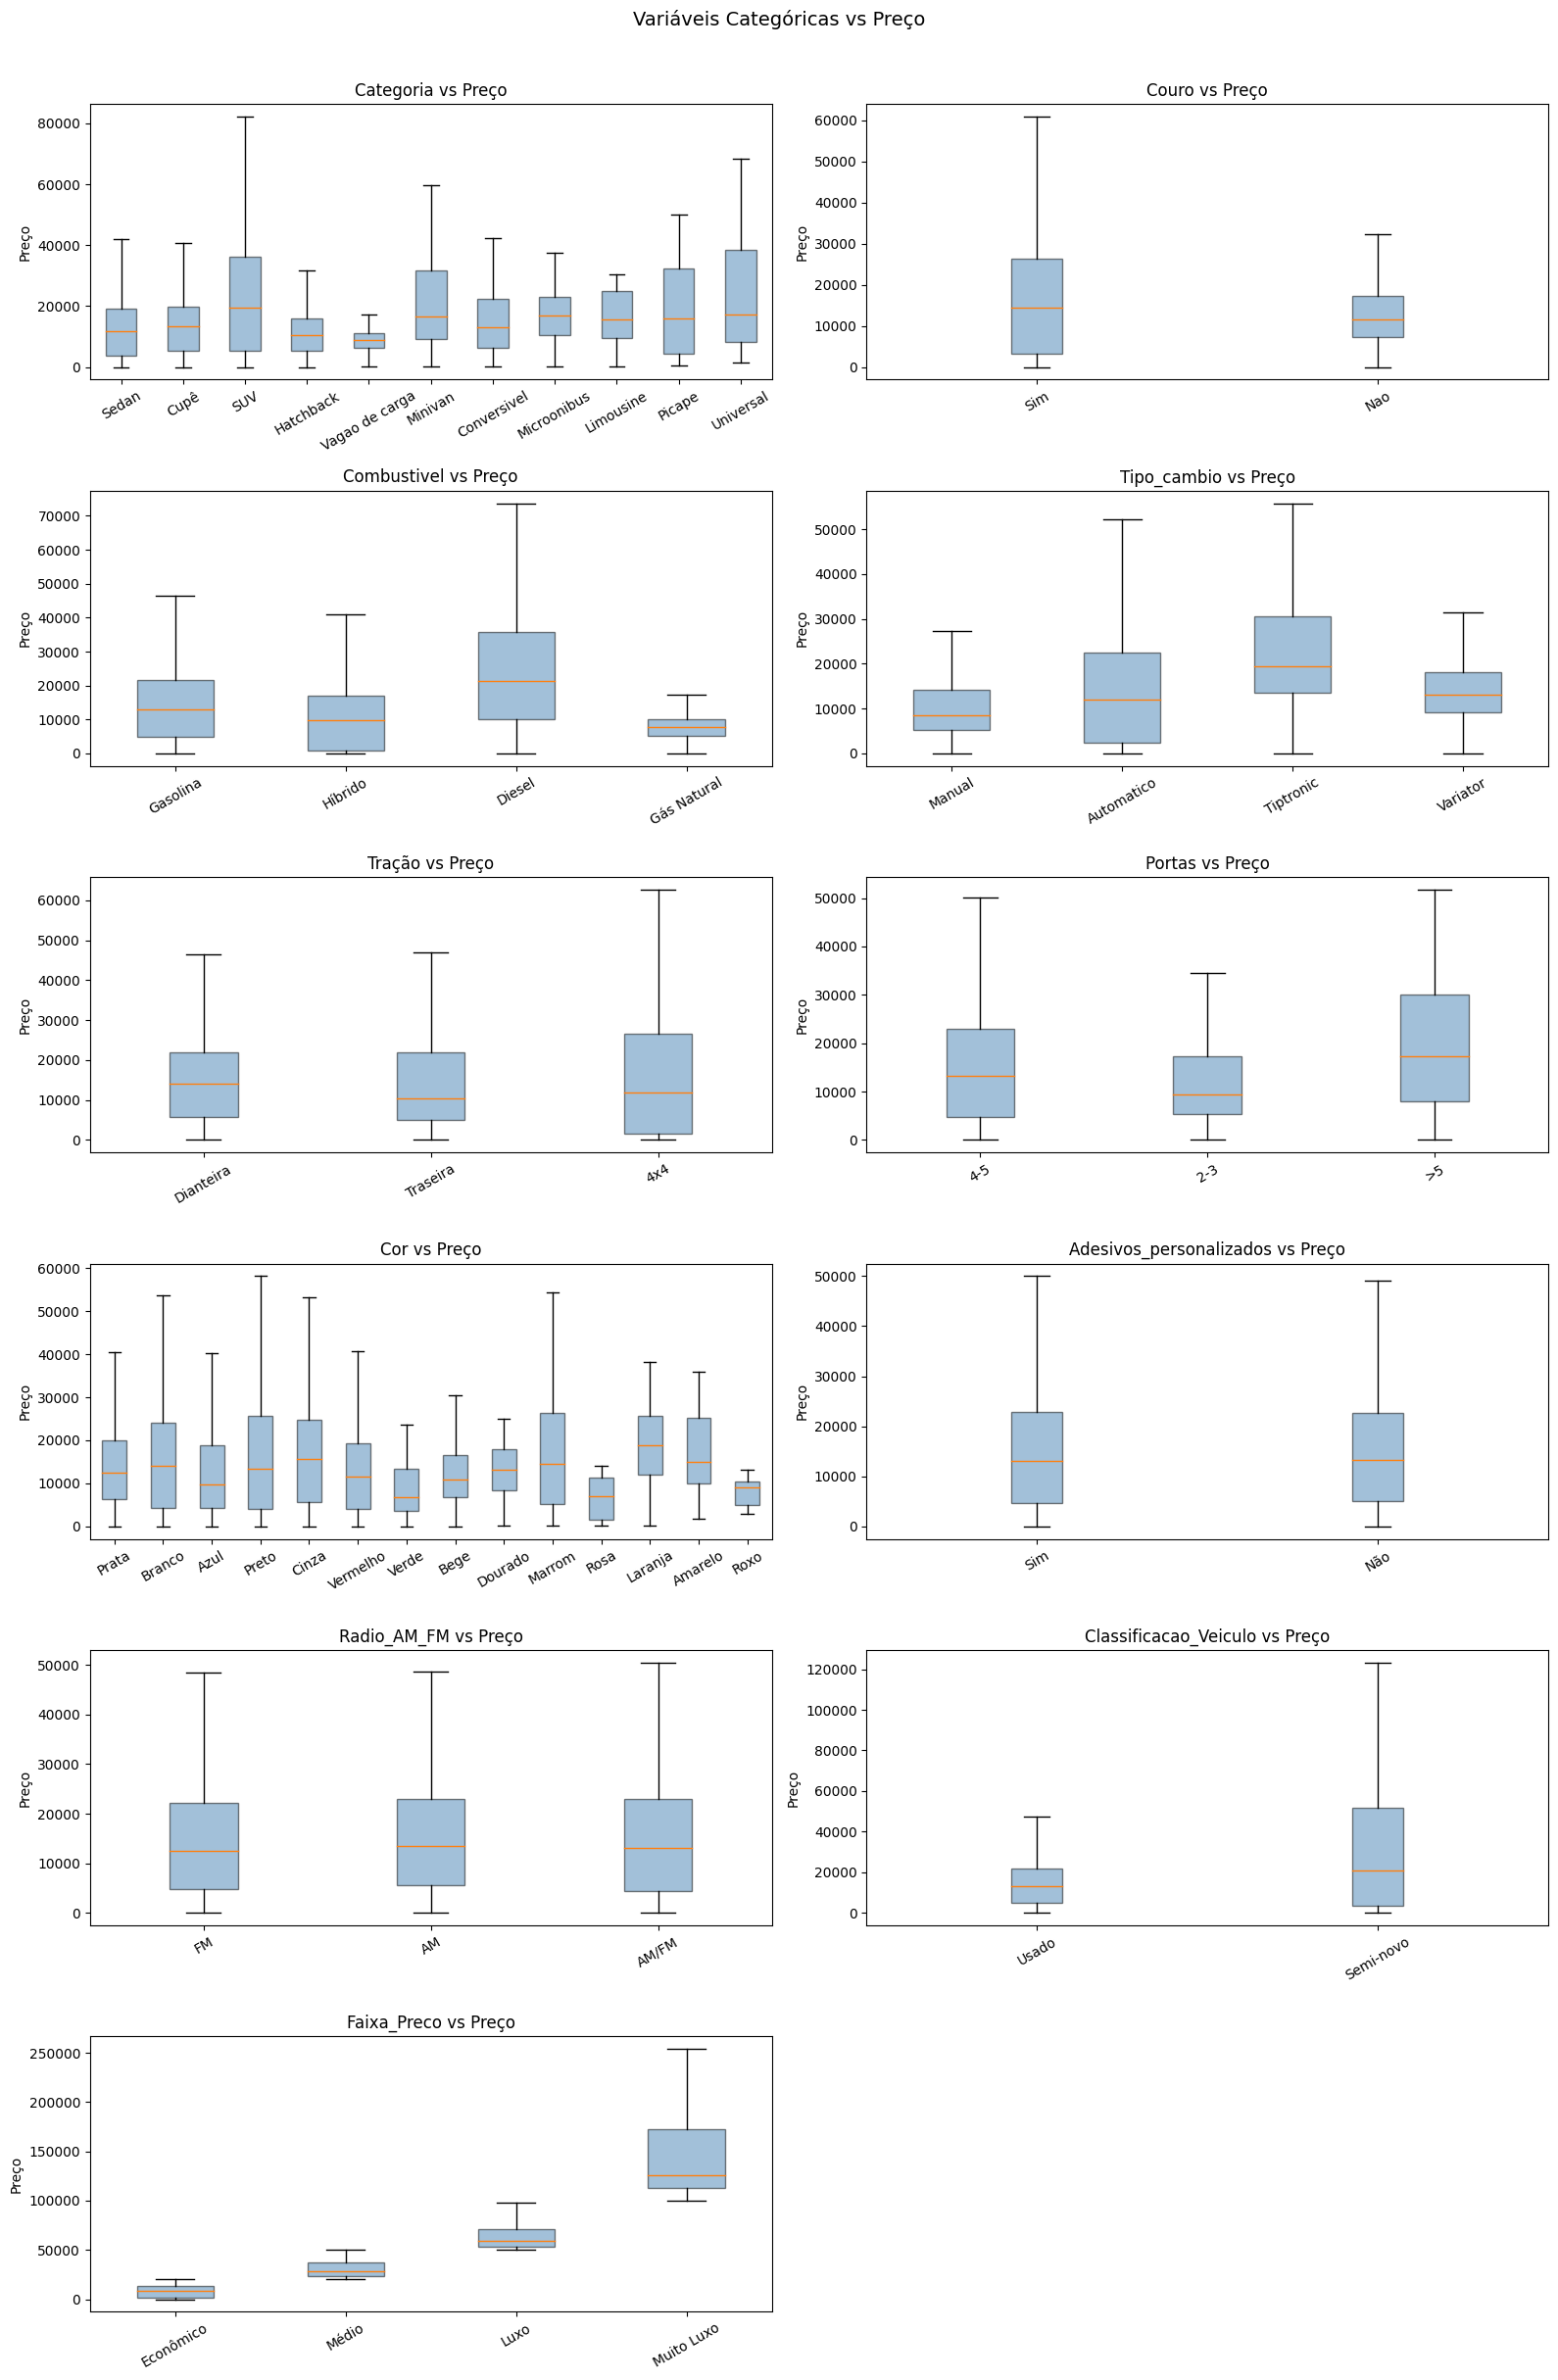

In [55]:
################ Análise de variáveis categóricas vs Preço

cat_cols = df.select_dtypes(include='object').columns.tolist()
# Excluir identificadores óbvios
cat_cols = [c for c in cat_cols if c not in ['ID', 'Modelo']]
# Boxplots para categóricas com poucas categorias
cat_plot = [c for c in cat_cols if df[c].nunique() <= 15]

n_cols = 2
n_rows = int(np.ceil(len(cat_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    grupos = [df.loc[df[col] == v, 'Preco'].dropna()
              for v in df[col].dropna().unique()]
    axes[i].boxplot(grupos, labels=df[col].dropna().unique(),
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(f'{col} vs Preço')
    axes[i].set_ylabel('Preço')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variáveis Categóricas vs Preço', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('categoricas_vs_preco.png', dpi=150, bbox_inches='tight')
plt.show()

Correlação de Pearson com Preço:
Km                      -0.212346
Ano                      0.207699
Idade                   -0.207699
Volume_motor             0.131691
Km_por_ano              -0.106921
Cilindros                0.103025
Débitos                  0.038674
Airbags                 -0.029852
Codigo_concessionaria    0.022922
Numero_proprietarios     0.015480
Historico_troca_oleo     0.010483


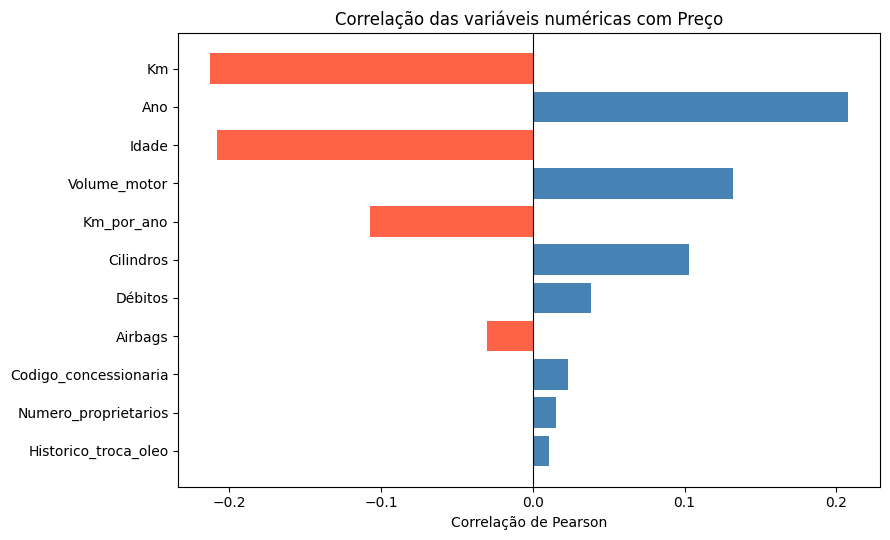

In [56]:
#################### Correlação de Pearson — variáveis numéricas vs Preço

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Preco']

correlacoes = (
    df[num_cols + ['Preco']]
    .corr()['Preco']
    .drop('Preco')
    .sort_values(key=abs, ascending=False)
)

print('Correlação de Pearson com Preço:')
print(correlacoes.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(9, max(4, len(correlacoes) * 0.5)))
cores = ['steelblue' if v >= 0 else 'tomato' for v in correlacoes]
ax.barh(correlacoes.index[::-1], correlacoes.values[::-1], color=cores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson')
ax.set_title('Correlação das variáveis numéricas com Preço')
plt.tight_layout()
#plt.savefig('correlacao_numericas.png', dpi=150)
plt.show()

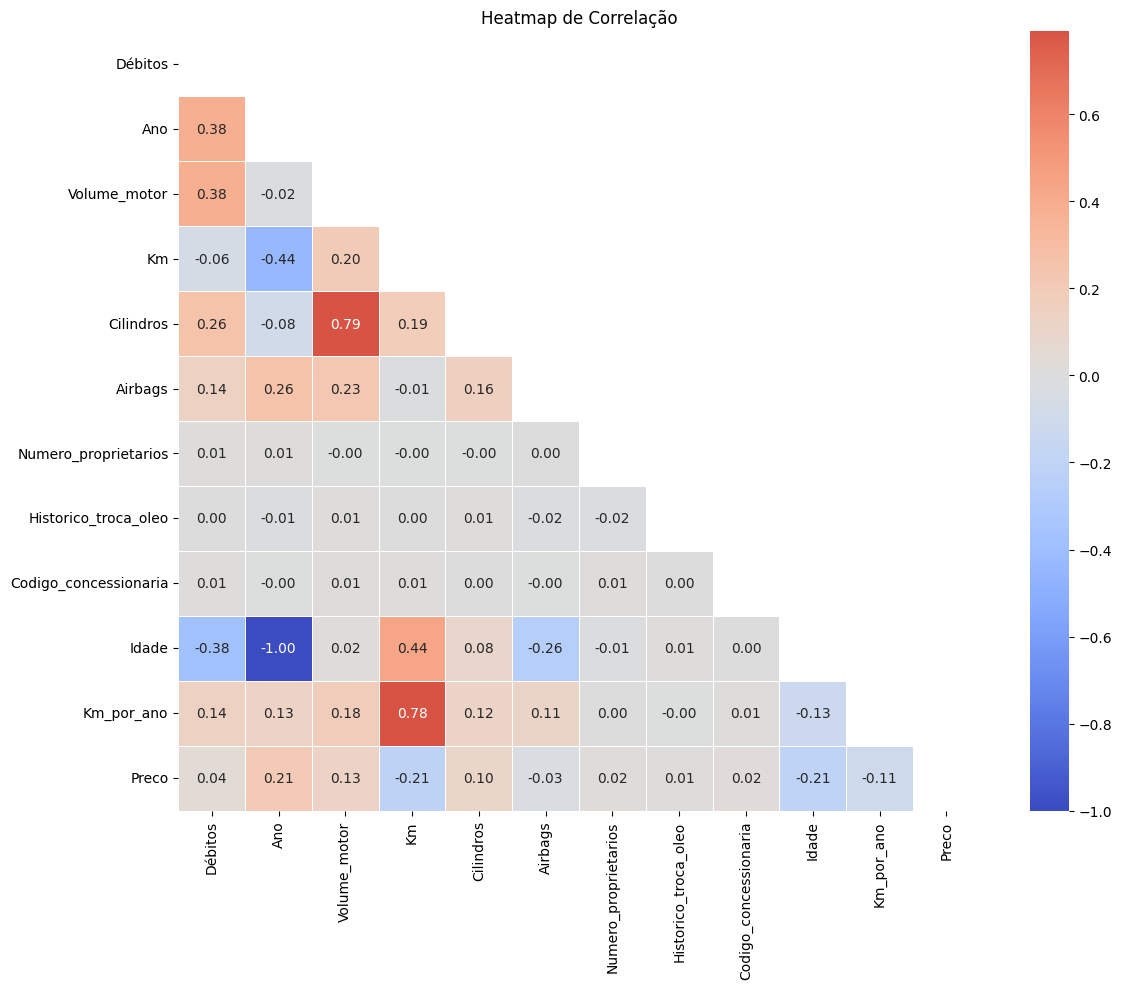

In [57]:
# Heatmap de correlação entre todas as variáveis numéricas
import seaborn as sns
df_num = df[num_cols + ['Preco']].select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(df_num.corr(), dtype=bool))
sns.heatmap(df_num.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Heatmap de Correlação')
plt.tight_layout()
#plt.savefig('heatmap_correlacao.png', dpi=150)
plt.show()

In [58]:
Q1 = df["Preco"].quantile(0.25)
Q3 = df["Preco"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_preco = df[(df["Preco"] < limite_inferior) | (df["Preco"] > limite_superior)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Q1: 4861.0
Q3: 22825.0
IQR: 17964.0
Limite inferior: -22085.0
Limite superior: 49771.0


In [59]:
outliers_preco.head(100)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
8084,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,3,2020-01-11,Não,AM/FM,6,1059,Usado,Médio,8,11694.375000
427,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,93555.0,4,...,2,2021-02-26,Não,FM,6,8004,Usado,Médio,8,11694.375000
2066,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,4,2020-05-15,Não,AM/FM,4,4812,Usado,Médio,7,18066.428571
266,1077.0,HYUNDAI,Tucson,2019,SUV,Sim,Diesel,2.0,48000.0,4,...,5,2020-01-18,Não,FM,7,6728,Semi-novo,Médio,4,12000.000000
4973,891.0,HYUNDAI,Santa FE,2016,SUV,Sim,Diesel,2.0,126465.0,4,...,1,2021-01-30,Sim,FM,3,3670,Usado,Médio,7,18066.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,1017.0,HYUNDAI,Sonata,2017,Sedan,Sim,Gasolina,2.0,37844.0,4,...,4,2022-08-13,Sim,FM,6,8255,Usado,Luxo,6,6307.333333
1818,0.0,MERCEDES-BENZ,Viano,2013,Minivan,Sim,Diesel,2.2,250000.0,4,...,5,2022-11-19,Não,FM,1,5973,Usado,Luxo,10,25000.000000
4493,1058.0,LEXUS,RX 450,2012,SUV,Sim,Híbrido,3.5,65000.0,6,...,4,2020-03-26,Não,AM/FM,3,2405,Usado,Luxo,11,5909.090909
3746,1327.0,TOYOTA,Camry,2018,Sedan,Sim,Gasolina,2.5,NaN,6,...,5,2021-04-23,Sim,AM,7,6060,Semi-novo,Luxo,5,NaN


In [60]:
df = df[df["Preco"].notna()].copy()
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7418,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.0,4,...,3,2022-03-01,Sim,FM,5,1816,Usado,Econômico,24,5092.958333
4524,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.0,4,...,3,2022-07-29,Não,AM,6,3838,Usado,Econômico,7,5857.142857
5588,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.0,4,...,5,2021-05-02,Sim,AM/FM,5,1003,Usado,Econômico,19,17263.157895
4701,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.0,4,...,5,2020-04-11,Não,AM/FM,10,7208,Usado,Econômico,9,14933.333333
715,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,NaN,6,...,4,2020-12-03,Sim,AM/FM,5,9266,Usado,Econômico,19,NaN


### Coluna Numero_proprietarios

In [61]:
df["Numero_proprietarios"].value_counts()

Numero_proprietarios
2    1711
5    1653
1    1638
3    1635
4    1624
Name: count, dtype: int64

In [62]:
df['Numero_proprietarios'].isna().sum()

0

### Coluna Data_ultima_lavagem

In [63]:
df["Data_ultima_lavagem"].value_counts()

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
              ..
2021-08-02     2
2021-02-21     2
2022-05-09     2
2020-02-12     1
2020-08-15     1
Name: count, Length: 1096, dtype: int64

In [64]:
df["Data_ultima_lavagem"].astype(str).value_counts().head(30)

Data_ultima_lavagem
2020-11-05    19
2021-04-08    18
2020-05-23    17
2020-07-26    17
2020-04-06    16
2021-02-03    16
2021-04-03    16
2020-11-20    16
2022-03-10    15
2022-06-28    15
2022-02-01    15
2021-09-02    15
2020-03-09    15
2021-07-06    15
2022-05-17    14
2021-10-23    14
2021-12-08    14
2022-06-11    14
2022-08-10    14
2020-02-16    14
2020-10-22    14
2020-01-04    14
2021-01-22    14
2022-09-07    14
2022-11-20    14
2020-07-25    14
2020-06-17    14
2020-03-30    14
2022-08-17    14
2022-06-22    14
Name: count, dtype: int64

In [65]:
df["Data_ultima_lavagem"] = pd.to_datetime(
    df["Data_ultima_lavagem"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [66]:
# definir a data de referência
data_ref = pd.Timestamp("2023-01-01")

# calcular quantos dias se passaram
df["Dias_desde_ultima_lavagem"] = (data_ref - df["Data_ultima_lavagem"]).dt.days

df[["Data_ultima_lavagem", "Dias_desde_ultima_lavagem"]].head()

,Data_ultima_lavagem,Dias_desde_ultima_lavagem
7418,2022-03-01,306
4524,2022-07-29,156
5588,2021-05-02,609
4701,2020-04-11,995
715,2020-12-03,759


In [67]:
df['Data_ultima_lavagem'].isna().sum()

0

### Coluna Adesivos_personalizados

In [68]:
df["Adesivos_personalizados"].value_counts()

Adesivos_personalizados
Sim    4195
Não    4066
Name: count, dtype: int64

In [69]:
df['Adesivos_personalizados'].isna().sum()

0

### Coluna Radio_AM_FM

In [70]:
df["Radio_AM_FM"].value_counts()

Radio_AM_FM
FM       2809
AM/FM    2794
AM       2658
Name: count, dtype: int64

In [71]:
df['Radio_AM_FM'].isna().sum()

0

### Coluna Historico_troca_oleo

In [72]:
df["Historico_troca_oleo"].value_counts()

Historico_troca_oleo
9     800
8     769
6     764
4     764
0     755
1     754
10    737
5     732
7     732
3     732
2     722
Name: count, dtype: int64

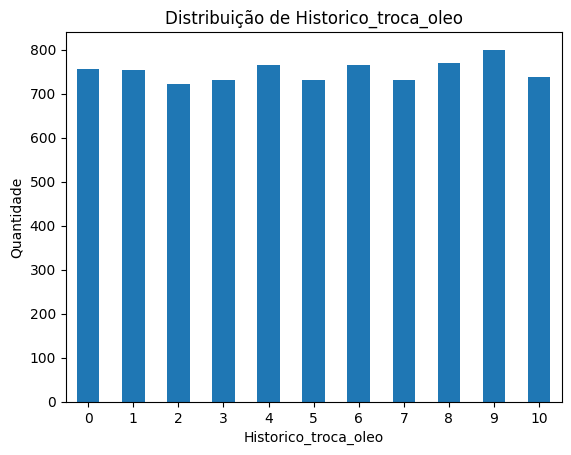

In [73]:
df["Historico_troca_oleo"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Historico_troca_oleo")
plt.ylabel("Quantidade")
plt.title("Distribuição de Historico_troca_oleo")
plt.xticks(rotation=0)
plt.show()

In [74]:
df['Historico_troca_oleo'].isna().sum()

0

### Coluna Codigo_concessionaria

In [75]:
df["Codigo_concessionaria"].value_counts()

Codigo_concessionaria
6890    7
7213    6
2423    6
7539    6
7544    6
       ..
2547    1
4126    1
1743    1
7302    1
9941    1
Name: count, Length: 5399, dtype: int64

In [76]:
colunas_excluir = ["Codigo_concessionaria"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Classificacao_Veiculo

In [77]:
df["Classificacao_Veiculo"].value_counts()

Classificacao_Veiculo
Usado        7889
Semi-novo     372
Name: count, dtype: int64

In [78]:
colunas_excluir = ["Classificacao_Veiculo"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Faixa_Preco

In [79]:
df["Faixa_Preco"].value_counts()

Faixa_Preco
Econômico     5745
Médio         2107
Luxo           352
Muito Luxo      57
Name: count, dtype: int64

In [80]:
colunas_excluir = ["Faixa_Preco"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Exportar para excel todos os possíveis valores das colunas

In [ ]:
import pandas as pd

lista = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False).reset_index()
    vc.columns = ["valor", "quantidade"]
    vc.insert(0, "coluna", col)
    lista.append(vc)

resultado = pd.concat(lista, ignore_index=True)
#resultado.to_excel("value_counts_todas_colunas.xlsx", index=False)

# ANOVA - seleção de features

### Aplica o teste F (ANOVA) para avaliar a significância estatística de cada feature em relação ao Preço. Features com p-value > 0.05 serão candidatas à exclusão.

In [82]:
# --- Preparar X para ANOVA ---
COLUNAS_REMOVER_EDA = [
    'ID', 'Faixa_Preco', 'Classificacao_Veiculo', 'Modelo',
    'Data_ultima_lavagem', 'Adesivos_personalizados', 'Codigo_concessionaria',
]

df_anova = df.drop(
    columns=[c for c in COLUNAS_REMOVER_EDA if c in df.columns]
).dropna(subset=['Preco'])

# Encodar categóricas para ANOVA
df_anova_enc = pd.get_dummies(df_anova, drop_first=True)
X_anova = df_anova_enc.drop(columns=['Preco']).fillna(df_anova_enc.drop(columns=['Preco']).mean())
y_anova = df_anova_enc['Preco']

# Converter bool → int
X_anova = X_anova.astype({c: int for c in X_anova.select_dtypes(include='bool').columns})
X_anova = X_anova.select_dtypes(include='number')

print(f'Features para ANOVA: {X_anova.shape[1]}')
print(f'Amostras           : {len(y_anova)}')

Features para ANOVA: 106
Amostras           : 8261


In [83]:
from sklearn.feature_selection import f_regression
f_scores, p_values = f_regression(X_anova, y_anova)

df_anova_result = pd.DataFrame({
    'Feature' : X_anova.columns,
    'F_score' : f_scores,
    'p_value' : p_values
}).sort_values('F_score', ascending=False)

print('=== ANOVA — Top 20 features ===')
print(df_anova_result.head(20).to_string(index=False))

=== ANOVA — Top 20 features ===
               Feature     F_score       p_value
Fabricante_LAMBORGHINI 1203.968877 2.175625e-246
                 Idade  372.346172  3.471619e-81
                   Ano  372.346172  3.471619e-81
                    Km  250.502270  1.318384e-55
 Tipo_cambio_Tiptronic  239.627349  2.646874e-53
         Categoria_SUV  230.534459  2.242236e-51
          Volume_motor  145.760803  2.789210e-33
   Combustivel_Híbrido  143.405273  8.945561e-33
    Fabricante_HYUNDAI  139.980979  4.872252e-32
    Fabricante_BENTLEY   94.030551  4.075068e-22
       Categoria_Sedan   90.926463  1.922091e-21
             Cilindros   88.602584  6.143488e-21
             Couro_Sim   85.459874  2.960188e-20
   Categoria_Hatchback   84.424022  4.971918e-20
            Km_por_ano   62.105122  3.670763e-15
  Fabricante_SSANGYONG   54.294601  1.892233e-13
    Tipo_cambio_Manual   46.068897  1.220486e-11
     Fabricante_TOYOTA   40.266357  2.332628e-10
 Fabricante_LAND ROVER   39.456681  3

In [84]:
# --- Features a REMOVER (p-value > 0.05) ---
ALPHA = 0.05
features_remover = df_anova_result[df_anova_result['p_value'] > ALPHA]['Feature'].tolist()

print(f'\nFeatures NÃO significativas (p > {ALPHA}): {len(features_remover)}')
for f in features_remover:
    pv = df_anova_result.loc[df_anova_result['Feature'] == f, 'p_value'].values[0]
    print(f'  {f:<40} p={pv:.4f}')

features_manter = df_anova_result[df_anova_result['p_value'] <= ALPHA]['Feature'].tolist()
print(f'\nFeatures mantidas: {len(features_manter)}')


Features NÃO significativas (p > 0.05): 59
  Fabricante_FORD                          p=0.0547
  Portas_>5                                p=0.0606
  Fabricante_FIAT                          p=0.0613
  Fabricante_JAGUAR                        p=0.0625
  Fabricante_MERCEDES-BENZ                 p=0.0971
  Cor_Cinza                                p=0.1136
  Categoria_Minivan                        p=0.1219
  Categoria_Picape                         p=0.1334
  Fabricante_SUZUKI                        p=0.1466
  Numero_proprietarios                     p=0.1595
  Fabricante_TESLA                         p=0.1696
  Fabricante_HUMMER                        p=0.1756
  Fabricante_DAIHATSU                      p=0.1787
  Fabricante_CHRYSLER                      p=0.2024
  Cor_Roxo                                 p=0.2137
  Fabricante_LEXUS                         p=0.2810
  Fabricante_RENAULT                       p=0.3038
  Radio_AM_FM_AM/FM                        p=0.3283
  Historico_troca_ol

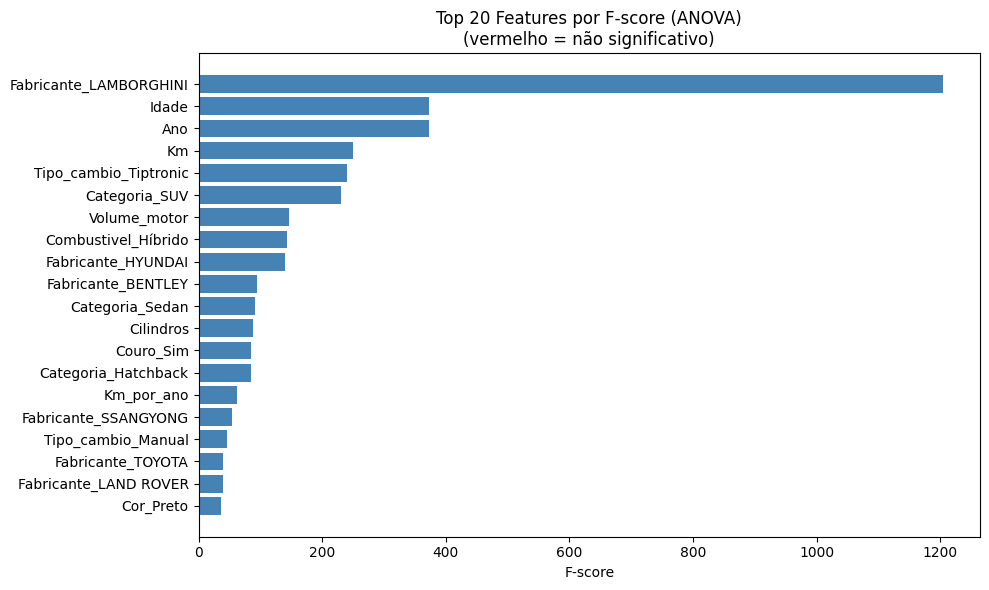

In [85]:
# --- Gráfico Top 20 ANOVA ---
top20 = df_anova_result.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['steelblue' if p <= ALPHA else 'tomato' for p in top20['p_value']]
ax.barh(top20['Feature'][::-1], top20['F_score'][::-1], color=cores[::-1])
ax.set_xlabel('F-score')
ax.set_title('Top 20 Features por F-score (ANOVA)\n(vermelho = não significativo)')
plt.tight_layout()
#plt.savefig('anova_top20.png', dpi=150)
plt.show()

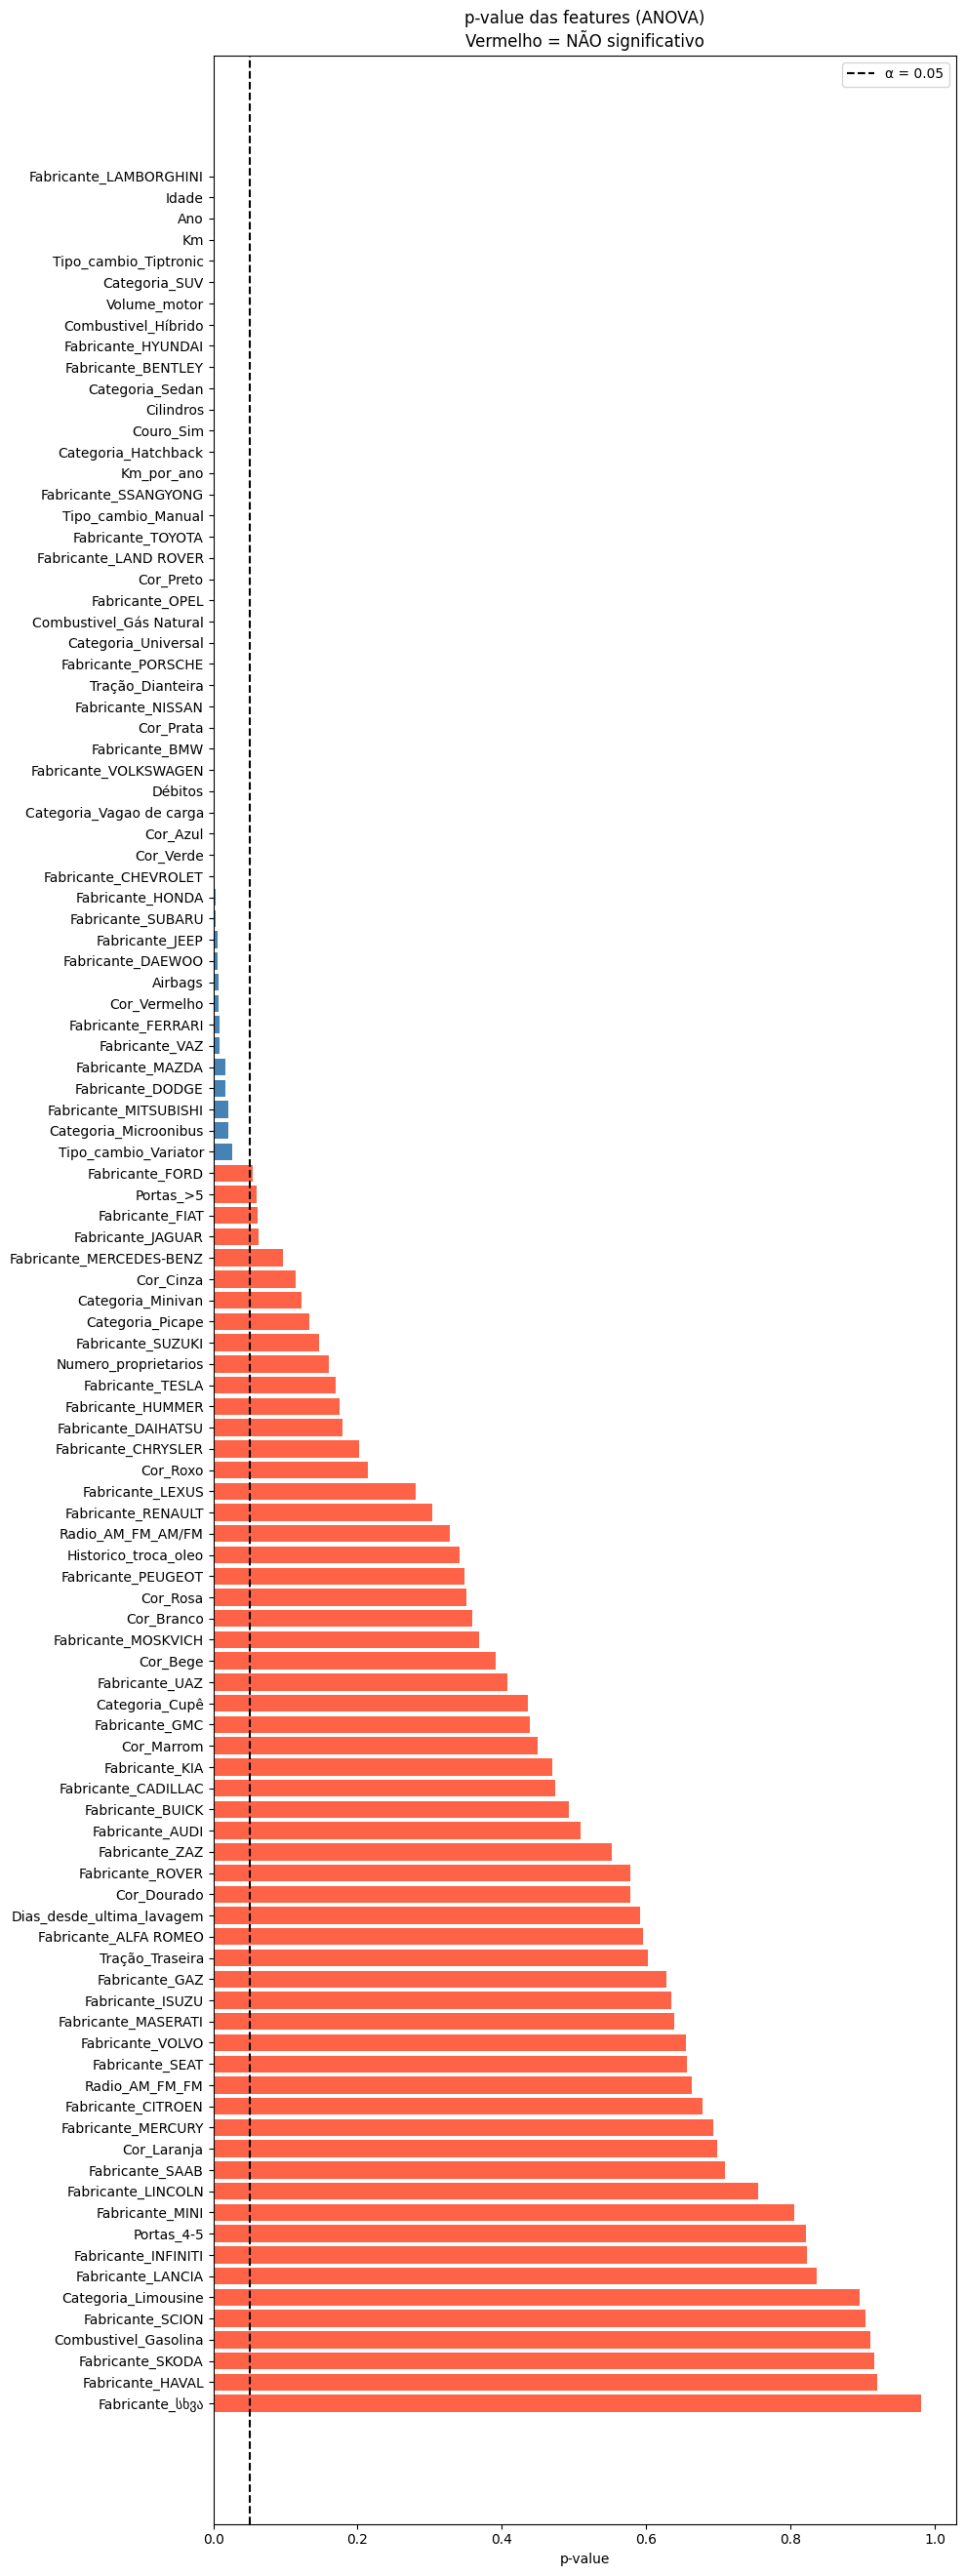

In [86]:
# --- Gráfico p-values ---
fig, ax = plt.subplots(figsize=(10, max(6, len(df_anova_result) * 0.25)))
cores_pv = ['tomato' if p > ALPHA else 'steelblue'
             for p in df_anova_result['p_value']]
ax.barh(df_anova_result['Feature'][::-1],
        df_anova_result['p_value'][::-1],
        color=cores_pv[::-1])
ax.axvline(ALPHA, color='black', linestyle='--', linewidth=1.5,
           label=f'α = {ALPHA}')
ax.set_xlabel('p-value')
ax.set_title('p-value das features (ANOVA)\nVermelho = NÃO significativo')
ax.legend()
plt.tight_layout()
#plt.savefig('anova_pvalues.png', dpi=150)
plt.show()

# Predição de valores ausentes na coluna km

In [87]:
                
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import StackingRegressor, HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import RidgeCV
# =========================================================
# 1. Dados
# =========================================================
# Features usadas para imputar Km.
numeric_features = ['Débitos', 'Idade', 'Volume_motor', 'Cilindros', 'Numero_proprietarios', 'Historico_troca_oleo']
categorical_features = ['Fabricante','Categoria', 'Couro', 'Combustivel', 'Tipo_cambio', 'Tração', 'Portas']
features_km = numeric_features + categorical_features

missing_features_km = [c for c in features_km if c not in df.columns]
if missing_features_km:
    raise ValueError(f'Colunas ausentes para prever Km: {missing_features_km}')

df_km_train = df[df['Km'].notna()].copy()
X_km = df_km_train[features_km]
y_km = df_km_train['Km']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_km, y_km, test_size=0.2, random_state=42)

preprocessor_km = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# INCLUINDO EXTRA TREES QUE VOCÊ USAVA E DAVA BOM RESULTADO
estimators = [
    ('et', ExtraTreesRegressor(n_estimators=400, max_depth=20, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist')),
    ('lgbm', LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1))
]

stacking_km = StackingRegressor(estimators=estimators, final_estimator=RidgeCV(), cv=5)

pipeline_km = TransformedTargetRegressor(
    regressor=Pipeline([('prep', preprocessor_km), ('model', stacking_km)]),
    func=np.log1p,
    inverse_func=np.expm1
)

# GRID SEARCH MAIS EXAUSTIVO PARA SUPERAR 0.42
param_grid_km = {
    'regressor__model__xgb__learning_rate': [0.01, 0.05],
    'regressor__model__lgbm__num_leaves': [31, 63],
    'regressor__model__et__max_depth': [20, 30]
}

print("Iniciando Grid Search Master para Km...")
grid_km = GridSearchCV(pipeline_km, param_grid_km, cv=3, scoring='r2', n_jobs=-1, verbose=2)
grid_km.fit(X_train_k, y_train_k)

best_r2 = grid_km.best_score_
print(f"Melhor R2 para Km no Treino: {best_r2:.4f}")

y_pred_k = grid_km.predict(X_test_k)
test_r2 = r2_score(y_test_k, y_pred_k)
print(f"R2 Score no Teste: {test_r2:.4f}")

Iniciando Grid Search Master para Km...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhor R2 para Km no Treino: 0.3755
R2 Score no Teste: 0.4056


In [88]:
# Treinar novamente, agora com todos os registros que tem Km conhecido,
# usando o melhor modelo escolhido pelo grid search.
km_faltante_antes_predicao = df["Km"].isna()
df["Km_imputado"] = km_faltante_antes_predicao.astype(int)

train_km_full = df[df["Km"].notna()].copy()
pred_km = df[km_faltante_antes_predicao].copy()

X_train_full = train_km_full[features_km]
y_train_full = train_km_full["Km"]

#melhor_nome_km = df_metricas.iloc[0]["Modelo"]
model_km_final = clone(grid_km.best_estimator_)
model_km_final.fit(X_train_full, y_train_full)

if len(pred_km) > 0:
    km_previsto = np.clip(model_km_final.predict(pred_km[features_km]), 0, None)
    df.loc[pred_km.index, "Km"] = km_previsto

# Atualizar a feature derivada depois da imputacao.
df["Km_por_ano"] = df["Km"] / df["Idade"]

#print("Modelo usado para imputar Km:", melhor_nome_km)
print("Faltantes restantes em Km:", df["Km"].isna().sum())
print("Registros com Km imputado:", df["Km_imputado"].sum())

Faltantes restantes em Km: 0
Registros com Km imputado: 1439


In [89]:
# Exporta uma copia completa do dataset tratado e uma versao encodada/filtrada por ANOVA para o modelo de preco.
from sklearn.feature_selection import f_regression

ALPHA_EXPORT = 0.05
TARGET_PRECO = 'Preco'

COLUNAS_REMOVER_EXPORT = [
    'ID', 'Faixa_Preco', 'Classificacao_Veiculo', 'Modelo',
    'Data_ultima_lavagem', 'Adesivos_personalizados', 'Codigo_concessionaria',
]

df_modelagem_preco = df.drop(
    columns=[c for c in COLUNAS_REMOVER_EXPORT if c in df.columns],
    errors='ignore'
).dropna(subset=[TARGET_PRECO]).copy()

df_modelagem_preco = df_modelagem_preco.replace([np.inf, -np.inf], np.nan)
df_modelagem_preco_enc = pd.get_dummies(df_modelagem_preco, drop_first=True)

X_anova_export = df_modelagem_preco_enc.drop(columns=[TARGET_PRECO])
bool_cols = X_anova_export.select_dtypes(include='bool').columns
X_anova_export[bool_cols] = X_anova_export[bool_cols].astype(int)
X_anova_export = X_anova_export.select_dtypes(include='number')
X_anova_export = X_anova_export.fillna(X_anova_export.median(numeric_only=True)).fillna(0)

y_anova_export = pd.to_numeric(df_modelagem_preco_enc[TARGET_PRECO], errors='coerce')
linhas_validas = y_anova_export.notna()
X_anova_export = X_anova_export.loc[linhas_validas]
y_anova_export = y_anova_export.loc[linhas_validas]

f_scores_export, p_values_export = f_regression(X_anova_export, y_anova_export)
f_scores_export = np.nan_to_num(f_scores_export, nan=0.0)
p_values_export = np.nan_to_num(p_values_export, nan=1.0)

df_anova_result_export = pd.DataFrame({
    'Feature': X_anova_export.columns,
    'F_score': f_scores_export,
    'p_value': p_values_export,
}).sort_values('F_score', ascending=False)

features_manter_export = df_anova_result_export.loc[
    df_anova_result_export['p_value'] <= ALPHA_EXPORT,
    'Feature'
].tolist()

df_export_anova = X_anova_export[features_manter_export].copy()
df_export_anova[TARGET_PRECO] = y_anova_export

df.to_csv('database/train_mod_tratado_completo.csv', index=False)
df_export_anova.to_csv('database/train_mod_tratado_anova.csv', index=False)
df_anova_result_export.to_csv('database/anova_features_preco.csv', index=False)

print('Dataset completo exportado: database/train_mod_tratado_completo.csv')
print('Dataset ANOVA exportado: database/train_mod_tratado_anova.csv')
print('Ranking ANOVA exportado: database/anova_features_preco.csv')
print('Features antes do ANOVA:', X_anova_export.shape[1])
print('Features mantidas pelo ANOVA:', len(features_manter_export))
print('Linhas exportadas:', len(df_export_anova))

Dataset completo exportado: database/train_mod_tratado_completo.csv
Dataset ANOVA exportado: database/train_mod_tratado_anova.csv
Ranking ANOVA exportado: database/anova_features_preco.csv
Features antes do ANOVA: 107
Features mantidas pelo ANOVA: 47
Linhas exportadas: 8261
